# Full-match character dataset builder

This notebook builds a character-level dataset from **real line crops** using only `full_match` rows from `artifacts/ocr_redesign/preprocess_sweep_glm_broad_v4/gray_x3_lanczos/label_scores.json`.

The flow is intentionally simple:
- load a full-match line
- crop the real measurement line from the DICOM ROI
- remove spaces from the gold text
- split the ink span into `N` vertical slices where `N = len(gold_text_without_spaces)`
- tighten each slice vertically to local ink
- save each slice with its gold character label

This notebook also visualizes the slices before export, then writes `train_manifest.json` and `val_manifest.json` compatible with `app.tools.train_char_fallback_model`.

In [50]:
from __future__ import annotations

import hashlib
import json
import sys
from collections import Counter
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np


def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "app" / "pipeline" / "echo_ocr_pipeline.py").is_file():
            return p
    raise RuntimeError("Run this notebook from the Master repo.")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

from app.io.dicom_loader import load_dicom_series
from app.ocr.preprocessing import preprocess_gray_x3_lanczos
from app.pipeline.ai_pipeline import PipelineConfig
from app.pipeline.echo_ocr_pipeline import (
    DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
    DEFAULT_SEGMENTATION_MODE,
    DEFAULT_TARGET_LINE_HEIGHT_PX,
    EchoOcrPipeline,
)
from app.pipeline.layout.echo_ocr_box_detector import TopLeftBlueGrayBoxDetector
from app.pipeline.layout.line_segmenter import LineSegmenter
from app.pipeline.ocr.ocr_engines import UnavailableOcrEngineError, build_engine
from app.pipeline.transcription.line_transcriber import crop_segment
from app.tools.batch.sweep_preprocessing_headless import _broad_configs, _build_preprocess_views
from app.tools.char_fallback_dataset_bootstrap import _default_charset, _safe_label_dirname
from app.validation.datasets import resolve_dataset_path

ARTIFACT_ROOT = REPO / "artifacts" / "ocr_redesign"
CONFIG_NAME = "gray_x3_lanczos"
SWEEP_STEM = "preprocess_sweep_glm_broad_v4"
LABEL_SCORES = ARTIFACT_ROOT / SWEEP_STEM / CONFIG_NAME / "label_scores.json"
LABELS_JSON = REPO / "labels" / "labels.json"
OUTPUT_DIR = ARTIFACT_ROOT / "full_match_char_dataset"
SPLIT_FILTER = "validation"
VAL_RATIO = 0.12
CHARSET = _default_charset()

print("REPO:", REPO)
print("LABEL_SCORES:", LABEL_SCORES)
print("LABELS_JSON:", LABELS_JSON)
print("OUTPUT_DIR:", OUTPUT_DIR)
print("SPLIT_FILTER:", SPLIT_FILTER)

REPO: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master
LABEL_SCORES: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master\artifacts\ocr_redesign\preprocess_sweep_glm_broad_v4\gray_x3_lanczos\label_scores.json
LABELS_JSON: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master\labels\labels.json
OUTPUT_DIR: C:\Users\G513\Documents\howest\Semester_5\Stage\StageOpdracht\Master\artifacts\ocr_redesign\full_match_char_dataset
SPLIT_FILTER: validation


In [51]:
def _compact_chars(text: str) -> str:
    return "".join(ch for ch in str(text or "") if not ch.isspace())


def _stable_ratio(key: str) -> float:
    digest = hashlib.sha1(key.encode("utf-8")).hexdigest()
    value = int(digest[:8], 16)
    return value / float(0xFFFFFFFF)


def _gray_u8(image: np.ndarray) -> np.ndarray:
    if image.ndim == 2:
        return image.astype(np.uint8, copy=False)
    if image.ndim == 3 and image.shape[-1] >= 3:
        return cv2.cvtColor(image[..., :3].astype(np.uint8, copy=False), cv2.COLOR_BGR2GRAY)
    if image.ndim == 3:
        return image[..., 0].astype(np.uint8, copy=False)
    raise ValueError(f"Unsupported image shape: {image.shape}")


def _binarize_for_dead_space_split(preprocessed_gray: np.ndarray) -> np.ndarray:
    """Match `notebooks/validation_failure_walkthrough.ipynb`: ink is white, background is black."""
    if preprocessed_gray.size == 0:
        return np.zeros((0, 0), dtype=np.uint8)

    g = preprocessed_gray
    if g.ndim == 3 and g.shape[-1] >= 3:
        g = cv2.cvtColor(g, cv2.COLOR_RGB2GRAY)
    elif g.ndim == 3 and g.shape[-1] == 1:
        g = g[..., 0]
    g = g.astype(np.uint8, copy=False)

    _, bw = cv2.threshold(g, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    if float((bw > 0).mean()) > 0.5:
        bw = cv2.bitwise_not(bw)
    return bw


def _morph_close_horizontal(bw: np.ndarray, *, k: int) -> np.ndarray:
    k = int(max(1, k))
    if k % 2 == 0:
        k += 1
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (k, 1))
    return cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel)


def _gap_runs(ink_cols: np.ndarray, x0: int, x1: int, *, max_ink: int) -> list[tuple[int, int]]:
    """Maximal x-intervals [s, e) where every column has ink count <= max_ink."""
    runs: list[tuple[int, int]] = []
    s: int | None = None
    x0i, x1i = int(x0), int(x1)
    mx = int(max(0, max_ink))
    for x in range(x0i, x1i):
        if int(ink_cols[x]) <= mx:
            if s is None:
                s = x
        else:
            if s is not None:
                runs.append((s, x))
                s = None
    if s is not None:
        runs.append((s, x1i))
    return runs


def _gap_run_mid(s: int, e: int) -> int:
    return int(s + (e - s - 1) // 2)


def _dp_pick_increasing(
    values: list[int],
    targets: list[int],
) -> list[int]:
    """Pick len(targets) strictly increasing indices into values (by index) minimizing sum |values[j]-targets[t]|."""
    k = len(targets)
    m = len(values)
    if k == 0:
        return []
    if m < k:
        raise ValueError("need at least as many candidates as picks")
    inf = 10**18
    dp = [[inf] * m for _ in range(k)]
    prev_i = [[-1] * m for _ in range(k)]
    for r in range(m):
        dp[0][r] = abs(int(values[r]) - int(targets[0]))
    for t in range(1, k):
        for r in range(t, m):
            best = inf
            best_q = -1
            for q in range(t - 1, r):
                v = dp[t - 1][q] + abs(int(values[r]) - int(targets[t]))
                if v < best:
                    best = v
                    best_q = q
            dp[t][r] = best
            prev_i[t][r] = best_q
    best_r = min(range(k - 1, m), key=lambda r: dp[k - 1][r])
    chain = [best_r]
    for t in range(k - 1, 0, -1):
        chain.append(prev_i[t][chain[-1]])
    chain.reverse()
    return [int(values[j]) for j in chain]


def _choose_valley_cut(
    ink_cols_gap: np.ndarray,
    ink_cols_score: np.ndarray,
    bw_cross: np.ndarray,
    *,
    lo: int,
    hi: int,
    ideal: int,
    valley_radius: int | None = None,
    gap_max_ink: int = 0,
) -> int:
    """Pick a cut x in [lo, hi).

    Priority:
    1) Gap columns where ink count <= ``gap_max_ink`` (0 = true background), closest to ``ideal``.
    2) Otherwise fall back to a smoothed valley score on ``ink_cols_score``, penalizing vertical ink crossings.
       When ``valley_radius`` is set, the valley scan is limited to ``ideal ± valley_radius`` (clipped to
       ``[lo, hi)``); gap columns always use the full feasible strip.
    """
    if hi <= lo + 1:
        return int(max(lo, min(hi, ideal)))

    h = int(bw_cross.shape[0])
    mid = max(1, h // 2)
    top = bw_cross[:mid, :]
    bot = bw_cross[mid:, :]
    half_thr = max(1.0, 0.08 * float(h))

    gap = ink_cols_gap.astype(np.int32, copy=False)
    gmx = int(max(0, gap_max_ink))
    gap_cols = [x for x in range(int(lo), int(hi)) if int(gap[x]) <= gmx]
    if gap_cols:
        return int(min(gap_cols, key=lambda x: abs(int(x) - int(ideal))))

    ink = ink_cols_score.astype(np.float32, copy=False)
    ink_s = cv2.GaussianBlur(ink.reshape(1, -1), (0, 0), sigmaX=1.2).reshape(-1)

    v_lo, v_hi = int(lo), int(hi)
    if valley_radius is not None:
        r = int(max(0, valley_radius))
        v_lo = max(v_lo, int(ideal) - r)
        v_hi = min(v_hi, int(ideal) + r + 1)
        if v_hi <= v_lo + 1:
            v_lo, v_hi = int(lo), int(hi)

    best_x = int(v_lo)
    best_score = float("inf")
    for x in range(int(v_lo), int(v_hi)):
        col_ink = float(ink_s[x])
        top_ink = float((top[:, x] > 0).sum())
        bot_ink = float((bot[:, x] > 0).sum())
        cross_pen = 0.0
        if col_ink > 0.0 and top_ink >= half_thr and bot_ink >= half_thr:
            cross_pen = 0.55 * float(col_ink)

        local_lo = max(0, x - 3)
        local_hi = min(int(ink_s.shape[0]), x + 4)
        local_max = float(np.max(ink_s[local_lo:local_hi])) if local_hi > local_lo else 1.0
        depth = local_max - col_ink

        dist = abs(float(x - ideal))
        score = float(col_ink) + 0.08 * dist - 0.55 * float(depth) + float(cross_pen)

        if score < best_score:
            best_score = score
            best_x = int(x)

    return int(best_x)


def _adaptive_char_boxes(
    line_image: np.ndarray,
    expected_text: str,
    *,
    valley_search_frac: float = 0.4,
    close_kernel_px: int = 1,
    gap_max_ink_px: int = 1,
) -> tuple[np.ndarray, np.ndarray, list[dict[str, int | str]], list[int]]:
    chars = _compact_chars(expected_text)
    if not chars:
        return np.zeros((0, 0), dtype=np.uint8), np.zeros((0,), dtype=np.int32), [], []

    proc = preprocess_gray_x3_lanczos(line_image)
    bw0 = _binarize_for_dead_space_split(proc)
    bw = bw0 if int(close_kernel_px) <= 1 else _morph_close_horizontal(bw0, k=int(close_kernel_px))
    h, w = bw.shape[:2]
    # Gap detection should use the *unclosed* mask so 1px gaps stay gaps.
    ink_cols_gap = (bw0 > 0).sum(axis=0).astype(np.int32)
    # Score path can use a lightly closed mask for stability, but gaps come from `ink_cols_gap`.
    ink_cols_score = (bw > 0).sum(axis=0).astype(np.int32)
    active = ink_cols_gap > 0
    if active.any():
        xs = np.flatnonzero(active)
        x0, x1 = int(xs[0]), int(xs[-1]) + 1
    else:
        x0, x1 = 0, w

    n = len(chars)
    span = max(1, x1 - x0)
    avg_width = max(1.0, span / float(n))
    search_radius = max(2, int(round(avg_width * float(valley_search_frac))))
    k_cuts = n - 1
    uniform_ideals = [x0 + int(round(span * (j + 1) / float(n))) for j in range(k_cuts)]

    gap_mx = int(max(0, gap_max_ink_px))
    cand_cols: list[int] = []
    effective_gap_mx = gap_mx
    for mx_ink in (gap_mx, gap_mx + 1):
        runs = _gap_runs(ink_cols_gap, x0, x1, max_ink=int(mx_ink))
        cols: list[int] = []
        for s, e in runs:
            mid = _gap_run_mid(s, e)
            if int(x0) < int(mid) < int(x1):
                cols.append(int(mid))
        cand_cols = sorted(set(cols))
        effective_gap_mx = int(mx_ink)
        if len(cand_cols) >= k_cuts:
            break

    if k_cuts > 0 and len(cand_cols) >= k_cuts:
        dp_targets = _dp_pick_increasing(cand_cols, uniform_ideals)
    else:
        dp_targets = list(uniform_ideals)

    cuts: list[int] = []
    left_bound = x0
    for i in range(1, n):
        ideal = int(dp_targets[i - 1])
        rem = n - i
        lo = int(left_bound) + 1
        hi_cap = int(x1) - int(rem) + 1
        hi = max(lo + 1, min(int(w), hi_cap))
        cut = _choose_valley_cut(
            ink_cols_gap,
            ink_cols_score,
            bw,
            lo=lo,
            hi=hi,
            ideal=ideal,
            valley_radius=int(search_radius),
            gap_max_ink=int(effective_gap_mx),
        )
        cuts.append(int(cut))
        left_bound = int(cut)

    bounds = [int(x0), *cuts, int(x1)]
    boxes: list[dict[str, int | str]] = []
    for i, ch in enumerate(chars):
        sx0 = int(bounds[i])
        sx1 = max(sx0 + 1, int(bounds[i + 1]))
        sub = bw0[:, sx0:sx1]
        ys = np.flatnonzero(sub.any(axis=1))
        if ys.size:
            y0, y1 = int(ys[0]), int(ys[-1]) + 1
        else:
            y0, y1 = 0, h
        boxes.append(
            {
                "char_index": i,
                "char": ch,
                "x0": int(sx0),
                "y0": int(y0),
                "x1": int(sx1),
                "y1": int(y1),
            }
        )
    return proc, ink_cols_gap, boxes, cuts


def _try_build_pipeline(config_name: str):
    sweep_cfg = next(c for c in _broad_configs() if c.name == config_name)
    preprocess_views = _build_preprocess_views(sweep_cfg)
    try:
        pipe = EchoOcrPipeline(
            ocr_engine=build_engine("glm-ocr"),
            config=PipelineConfig(
                parameters={
                    "ocr_engine": "glm-ocr",
                    "requested_ocr_engine": "glm-ocr",
                    "parser_mode": "off",
                }
            ),
        )
        pipe.ensure_components()
        pipe._line_transcriber.preprocess_views = preprocess_views
        return pipe
    except (UnavailableOcrEngineError, Exception) as exc:
        print("GLM pipeline unavailable, using raw segmentation fallback:", exc)
        return None


detector = TopLeftBlueGrayBoxDetector()
segmenter = LineSegmenter(
    segmentation_mode=DEFAULT_SEGMENTATION_MODE,
    target_line_height_px=DEFAULT_TARGET_LINE_HEIGHT_PX,
    extra_left_pad_px=DEFAULT_SEGMENTATION_EXTRA_LEFT_PAD_PX,
)
pipe = _try_build_pipeline(CONFIG_NAME)


def _extract_line_crop(fd: dict[str, object], match_ix: int) -> tuple[Path, np.ndarray, int]:
    dicom_path = resolve_dataset_path(fd, LABELS_JSON)
    series = load_dicom_series(dicom_path, load_pixels=True)
    frame = series.raw_frames[0]

    detection = detector.detect(frame)
    if not detection.present or detection.bbox is None:
        raise RuntimeError(f"ROI not found for {dicom_path}")

    x, y, bw, bh = detection.bbox
    roi = frame[y : y + bh, x : x + bw].copy()
    segmentation = segmenter.segment(roi, tokens=None)
    measurements = []
    if pipe is not None:
        try:
            _det, segmentation, _ocr, _panel, measurements, _bbox = pipe.analyze_frame_with_debug(frame)
        except Exception:
            segmentation = segmenter.segment(roi, tokens=None)
            measurements = []

    usable = list(segmentation.lines)
    match_to_panel: dict[int, int] = {}
    for mx, measurement in enumerate(measurements):
        hint = getattr(measurement, "order_hint", None)
        if hint is None:
            continue
        hint = int(hint)
        if 0 <= hint < len(usable):
            match_to_panel[int(mx)] = hint

    panel_ix = match_to_panel.get(int(match_ix), int(match_ix))
    if not (0 <= panel_ix < len(usable)):
        raise RuntimeError(f"panel line index {panel_ix} out of range for {dicom_path.name}")

    raw_line = crop_segment(roi, usable[panel_ix])
    if raw_line.size == 0:
        raise RuntimeError(f"Empty line crop for {dicom_path.name} match {match_ix}")
    return dicom_path, raw_line, int(panel_ix)

In [52]:
ls = json.loads(LABEL_SCORES.read_text(encoding="utf-8"))
full_match_rows: list[dict[str, object]] = []
char_counts: Counter[str] = Counter()

for fd in ls.get("file_details", []):
    if not isinstance(fd, dict):
        continue
    if str(fd.get("split") or "") != SPLIT_FILTER:
        continue
    matches = fd.get("matches") if isinstance(fd.get("matches"), list) else []
    for match_ix, match in enumerate(matches):
        if not isinstance(match, dict):
            continue
        if not bool(match.get("full_match", False)):
            continue
        expected_text = str(match.get("expected_text") or "").strip()
        compact = _compact_chars(expected_text)
        if not compact:
            continue
        for ch in compact:
            if ch in CHARSET:
                char_counts[ch] += 1
        full_match_rows.append(
            {
                "fd": fd,
                "match_ix": int(match_ix),
                "file_name": str(fd.get("file_name") or ""),
                "expected_text": expected_text,
                "compact_text": compact,
            }
        )

print("Full-match candidate lines:", len(full_match_rows))
print("Unique DICOMs:", len({str(r['file_name']) for r in full_match_rows}))
print("Character support:")
print({ch: int(char_counts.get(ch, 0)) for ch in CHARSET if char_counts.get(ch, 0) > 0})
full_match_rows[:5]

Full-match candidate lines: 898
Unique DICOMs: 353
Character support:
{'0': 309, '1': 657, '2': 496, '3': 228, '4': 308, '5': 203, '6': 180, '7': 154, '8': 163, '9': 148, '.': 690, '/': 223, '-': 56, '%': 67, 'c': 445, 'm': 1223, 'L': 513, 'A': 656, 'o': 70, 'E': 219, 'V': 775, 'I': 136, 'D': 260, 'T': 245}


[{'fd': {'file_path': 'C:\\Users\\G513\\Documents\\howest\\Semester_5\\Stage\\StageOpdracht\\database_stage\\files\\p10\\p10002221\\s94106955\\94106955_0011.dcm',
   'file_name': '94106955_0011.dcm',
   'split': 'validation',
   'status': 'ok',
   'error': None,
   'expected_lines': ['1 Ao Diam 3.2 cm'],
   'predicted_measurements': [{'name': '1 Ao Diam',
     'value': '3.2',
     'unit': 'cm'},
    {'name': '1 Ao Diam 3.2 cm', 'value': None, 'unit': None}],
   'exact_matches': 1,
   'line_matches': 1,
   'value_matches': 1,
   'label_matches': 1,
   'prefix_matches': 1,
   'total_labels': 1,
   'matches': [{'expected_text': '1 Ao Diam 3.2 cm',
     'predicted_text': '1 Ao Diam 3.2 cm',
     'line_match': True,
     'prefix_match': True,
     'label_match': True,
     'value_match': True,
     'unit_match': True,
     'full_match': True}]},
  'match_ix': 0,
  'file_name': '94106955_0011.dcm',
  'expected_text': '1 Ao Diam 3.2 cm',
  'compact_text': '1AoDiam3.2cm'},
 {'fd': {'file_path'

file: 94106955_0011.dcm
match_ix: 0 | panel_ix: 1
expected_text: '1 Ao Diam 3.2 cm'
compact_text: '1AoDiam3.2cm'
adaptive_boxes: 12


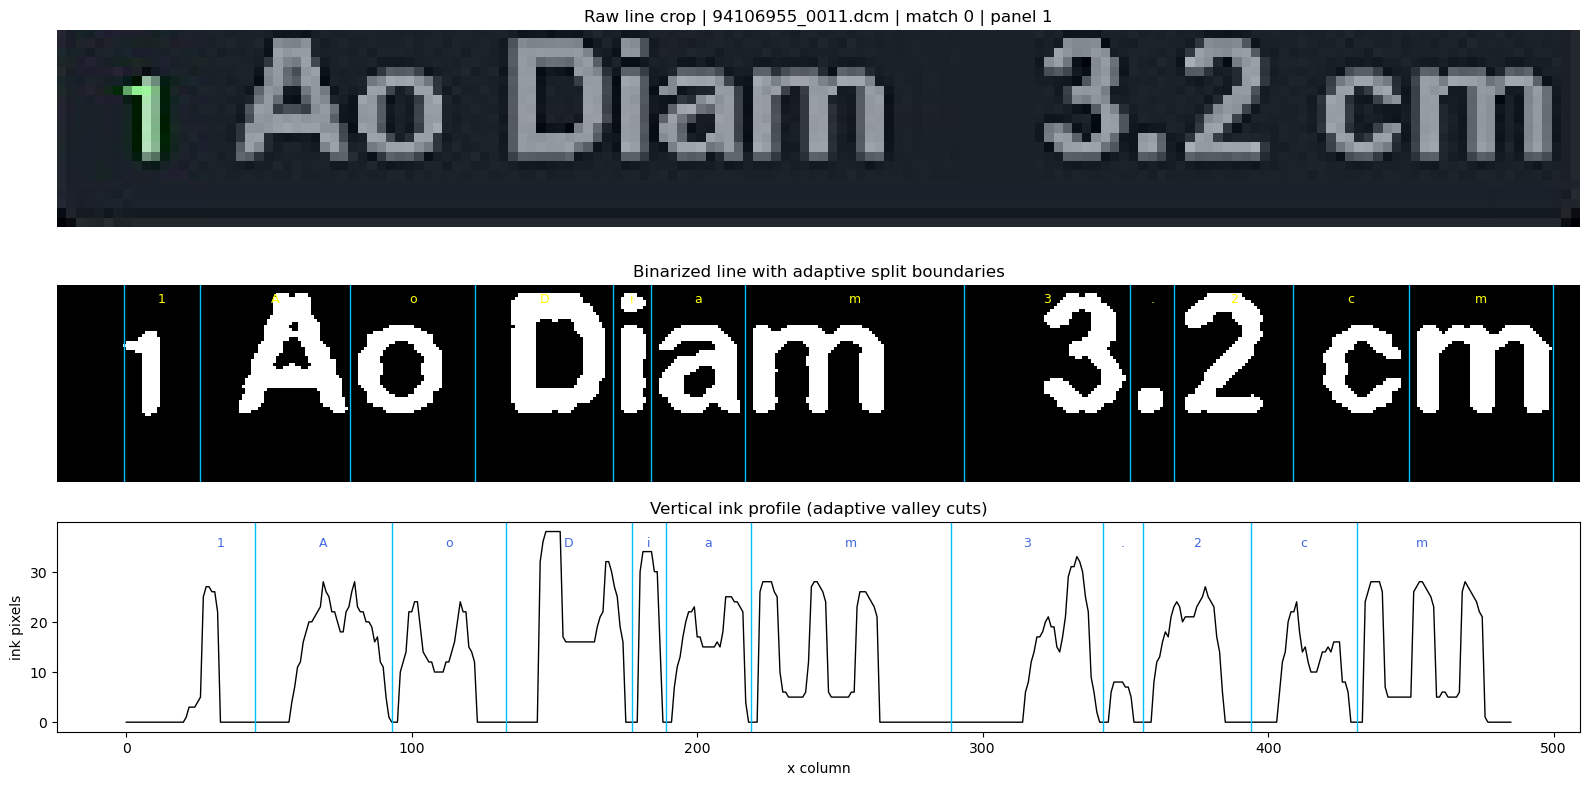

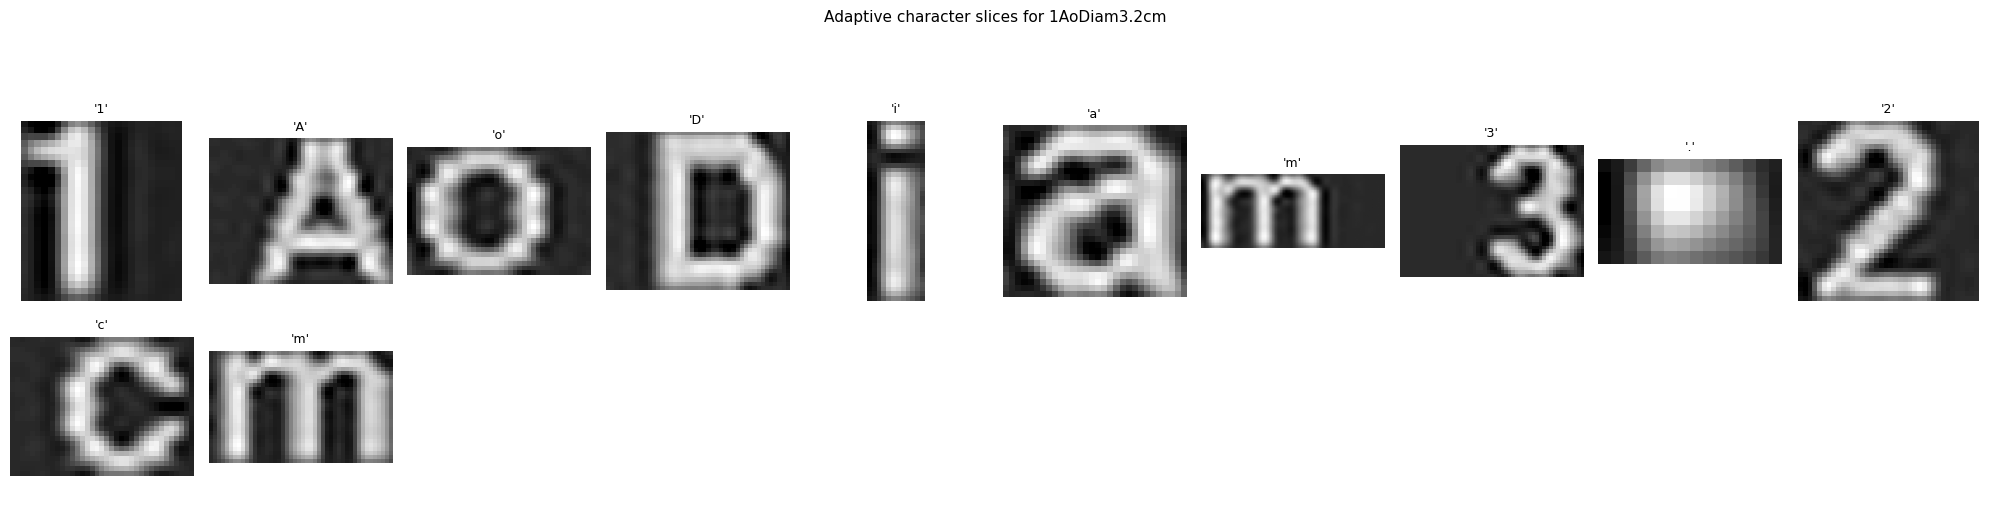

[{'char_index': 0, 'char': '1', 'x0': 21, 'y0': 15, 'x1': 45, 'y1': 42},
 {'char_index': 1, 'char': 'A', 'x0': 45, 'y0': 3, 'x1': 93, 'y1': 41},
 {'char_index': 2, 'char': 'o', 'x0': 93, 'y0': 13, 'x1': 133, 'y1': 41},
 {'char_index': 3, 'char': 'D', 'x0': 133, 'y0': 3, 'x1': 177, 'y1': 41},
 {'char_index': 4, 'char': 'i', 'x0': 177, 'y0': 3, 'x1': 189, 'y1': 41},
 {'char_index': 5, 'char': 'a', 'x0': 189, 'y0': 13, 'x1': 219, 'y1': 41},
 {'char_index': 6, 'char': 'm', 'x0': 219, 'y0': 13, 'x1': 289, 'y1': 41},
 {'char_index': 7, 'char': '3', 'x0': 289, 'y0': 3, 'x1': 342, 'y1': 41},
 {'char_index': 8, 'char': '.', 'x0': 342, 'y0': 33, 'x1': 356, 'y1': 41},
 {'char_index': 9, 'char': '2', 'x0': 356, 'y0': 3, 'x1': 394, 'y1': 41}]

In [53]:
SAMPLE_INDEX = 0  # change to inspect another full-match line
sample = full_match_rows[SAMPLE_INDEX]
dicom_path, raw_line, panel_ix = _extract_line_crop(sample["fd"], int(sample["match_ix"]))
proc_line, ink_profile, boxes, cut_cols = _adaptive_char_boxes(raw_line, str(sample["expected_text"]))
bw_line = _binarize_for_dead_space_split(proc_line)

print("file:", dicom_path.name)
print("match_ix:", sample["match_ix"], "| panel_ix:", panel_ix)
print("expected_text:", repr(sample["expected_text"]))
print("compact_text:", repr(sample["compact_text"]))
print("adaptive_boxes:", len(boxes))

fig, axes = plt.subplots(3, 1, figsize=(16, 8), gridspec_kw={"height_ratios": [1.0, 1.0, 0.9]})
axes[0].imshow(raw_line)
axes[0].set_title(f"Raw line crop | {dicom_path.name} | match {sample['match_ix']} | panel {panel_ix}")
axes[0].axis("off")

axes[1].imshow(bw_line, cmap="gray")
for b in boxes:
    axes[1].axvline(int(b["x0"]), color="deepskyblue", linewidth=1)
    axes[1].text((int(b["x0"]) + int(b["x1"])) / 2.0, 2, str(b["char"]), color="yellow", fontsize=9, ha="center", va="top")
if boxes:
    axes[1].axvline(int(boxes[-1]["x1"]), color="deepskyblue", linewidth=1)
axes[1].set_title("Binarized line with adaptive split boundaries")
axes[1].axis("off")

axes[2].plot(ink_profile, color="black", linewidth=1)
for c in cut_cols:
    axes[2].axvline(int(c), color="deepskyblue", linewidth=1)
y_text = max(float(ink_profile.max()), 1.0) * 0.92 if ink_profile.size else 1.0
for b in boxes:
    axes[2].text((int(b["x0"]) + int(b["x1"])) / 2.0, y_text, str(b["char"]), color="royalblue", fontsize=9, ha="center")
axes[2].set_title("Vertical ink profile (adaptive valley cuts)")
axes[2].set_xlabel("x column")
axes[2].set_ylabel("ink pixels")
plt.tight_layout()
plt.show()

cols = min(10, max(1, len(boxes)))
rows_n = (len(boxes) + cols - 1) // cols
fig2, axes2 = plt.subplots(rows_n, cols, figsize=(2.0 * cols, 2.3 * rows_n + 0.45))
axes2 = np.atleast_1d(axes2).ravel()
for ax, b in zip(axes2, boxes, strict=False):
    y0, y1 = int(b['y0']), int(b['y1'])
    x0, x1 = int(b['x0']), int(b['x1'])
    # Boxes are in preprocessed (×3) coordinates — same space as binarized middle panel.
    glyph = proc_line[y0:y1, x0:x1]
    if glyph.ndim == 3:
        glyph = _gray_u8(glyph)
    if glyph.size == 0:
        glyph = np.zeros((1, 1), dtype=np.uint8)
    ax.imshow(glyph, cmap="gray")
    ax.set_title(repr(str(b["char"])), fontsize=9)
    ax.axis("off")
for ax in axes2[len(boxes):]:
    ax.axis("off")
fig2.suptitle(f"Adaptive character slices for {sample['compact_text']}", fontsize=11, y=0.995)
fig2.tight_layout(rect=(0.0, 0.0, 1.0, 0.90))
plt.show()

boxes[:10]

In [ ]:
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
rows: list[dict[str, object]] = []
rejected: list[dict[str, object]] = []
class_counts: Counter[str] = Counter()
accepted_lines = 0
sample_seq = 0

for row in full_match_rows:
    fd = row["fd"]
    match_ix = int(row["match_ix"])
    expected_text = str(row["expected_text"])
    compact = str(row["compact_text"])
    try:
        dicom_path, raw_line, panel_ix = _extract_line_crop(fd, match_ix)
        proc_line, ink_profile, boxes, cut_cols = _adaptive_char_boxes(raw_line, expected_text)
    except Exception as exc:
        rejected.append(
            {
                "file_name": str(row["file_name"]),
                "match_ix": match_ix,
                "expected_text": expected_text,
                "reason": str(exc),
            }
        )
        continue

    if len(boxes) != len(compact):
        rejected.append(
            {
                "file_name": str(row["file_name"]),
                "match_ix": match_ix,
                "expected_text": expected_text,
                "reason": f"adaptive_box_count_mismatch:{len(boxes)}:{len(compact)}",
            }
        )
        continue

    accepted_lines += 1
    for box in boxes:
        char_label = str(box["char"])
        if char_label not in CHARSET:
            continue
        x0, y0, x1, y1 = int(box["x0"]), int(box["y0"]), int(box["x1"]), int(box["y1"])
        crop = proc_line[y0:y1, x0:x1]
        if crop.ndim == 3:
            crop = _gray_u8(crop)
        if crop.size == 0:
            continue

        sample_id = f"fm_{sample_seq:06d}_{int(box['char_index']):02d}"
        sample_seq += 1
        crop_path = OUTPUT_DIR / "crops" / "full_match" / _safe_label_dirname(char_label) / f"{sample_id}.png"
        crop_path.parent.mkdir(parents=True, exist_ok=True)
        cv2.imwrite(str(crop_path), crop)

        split_name = "val" if _stable_ratio(f"{dicom_path}|{match_ix}|{box['char_index']}|{char_label}") < float(VAL_RATIO) else "train"
        item = {
            "sample_id": sample_id,
            "label": char_label,
            "split": split_name,
            "low_trust": False,
            "source": "full_match_adaptive",
            "file_path": str(dicom_path),
            "expected_text": expected_text,
            "predicted_text": str(expected_text),
            "full_match_line": True,
            "split_confidence": 1.0,
            "match_index": match_ix,
            "panel_line_index": int(panel_ix),
            "char_index": int(box["char_index"]),
            "slice_box": [x0, y0, x1, y1],
            "cut_columns": [int(c) for c in cut_cols],
            "image_path": str(crop_path.relative_to(OUTPUT_DIR).as_posix()),
        }
        rows.append(item)
        class_counts[char_label] += 1

train_rows = [r for r in rows if r["split"] == "train"]
val_rows = [r for r in rows if r["split"] == "val"]
manifest = {
    "kind": "full_match_char_dataset",
    "label_scores": str(LABEL_SCORES),
    "labels_json": str(LABELS_JSON),
    "split_filter": SPLIT_FILTER,
    "charset": CHARSET,
    "line_rows": len(full_match_rows),
    "accepted_lines": int(accepted_lines),
    "accepted_samples": len(rows),
    "rejected": rejected,
    "class_balance": {ch: int(class_counts.get(ch, 0)) for ch in CHARSET},
    "rows": rows,
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")
(OUTPUT_DIR / "train_manifest.json").write_text(json.dumps({"charset": CHARSET, "split": "train", "samples": train_rows}, indent=2) + "\n", encoding="utf-8")
(OUTPUT_DIR / "val_manifest.json").write_text(json.dumps({"charset": CHARSET, "split": "val", "samples": val_rows}, indent=2) + "\n", encoding="utf-8")

print({
    "accepted_lines": accepted_lines,
    "accepted_samples": len(rows),
    "train_samples": len(train_rows),
    "val_samples": len(val_rows),
    "rejected": len(rejected),
})
print({ch: int(class_counts.get(ch, 0)) for ch in CHARSET if class_counts.get(ch, 0) > 0})

## Train the char CNN

After the export cell writes the manifests, train the existing model with:

```powershell
mamba run -n DL python -m app.tools.train_char_fallback_model `
  --dataset-dir artifacts/ocr_redesign/full_match_char_dataset `
  --output-root artifacts/ocr_redesign/char_model `
  --device auto `
  --cnn-variant medium
```

`medium` is the right first baseline for this dataset size. Once that model exists, return to `notebooks/validation_failure_walkthrough.ipynb` and run the bottom char-CNN evaluation section on the 3 failure cases.